# Exploratory Analysis PSDO

In [16]:
# Impot libraries
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt

In [2]:
# Import processed data from csv
# Define the path to the processed data based on the current user
current_user = os.getlogin()
if current_user == "bouba.ismalia":
    PROC_DIR = Path(rf"C:\Users\{current_user}\Stichting Hogeschool Utrecht\FCA-DA-P - data\processed")
else:
    PROC_DIR = Path(rf"C:\Users\{current_user}\Stichting Hogeschool Utrecht\FCA-DA-P - Analytics\Student drop-out\data\processed")

# Read the processed data
data = pd.read_csv(PROC_DIR / "v2_combined.csv")

## Analyse SKC relation with drop-out

sdo2_skc_ADVIES_DEF
Positief                        42.114153
Neutraal                        30.215002
Positief met aandachtspunten    15.385899
Missing                         10.656268
Negatief                         1.292933
Vrijstelling                     0.252330
Niet deelgenomen                 0.083415
Name: proportion, dtype: float64
sdo5_degree_COLLEGEJAAR       2018  2019  2020  2021  2022  2023
sdo2_skc_ADVIES_DEF                                             
Missing                       1319   793   800   756   703   739
Negatief                       258   255    10     9    49    39
Neutraal                       715   613  6204  5397   833   727
Niet deelgenomen                 9    10     2     2    12     5
Positief                      3861  4279  1005  1248  4565  5237
Positief met aandachtspunten  2153  1944   352   426  1357  1146
Vrijstelling                    72     7     2     2    10    28


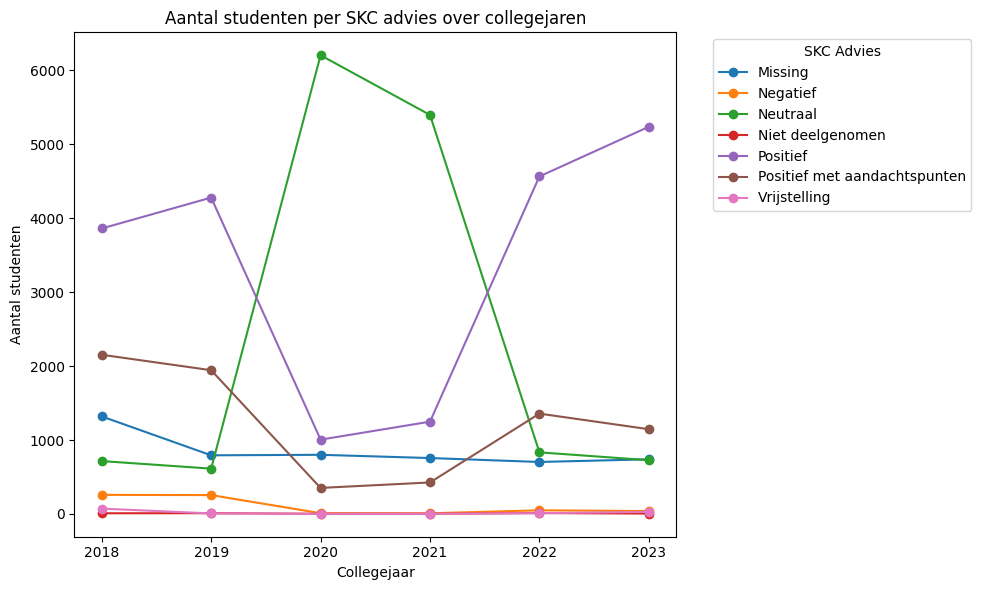

sdo5_degree_drop_out                  0          1
sdo2_skc_ADVIES_DEF                               
Positief                      67.907898  32.092102
Neutraal                      65.394437  34.605563
Positief met aandachtspunten  58.620222  41.379778
Missing                       76.634051  23.365949
Negatief                      54.516129  45.483871


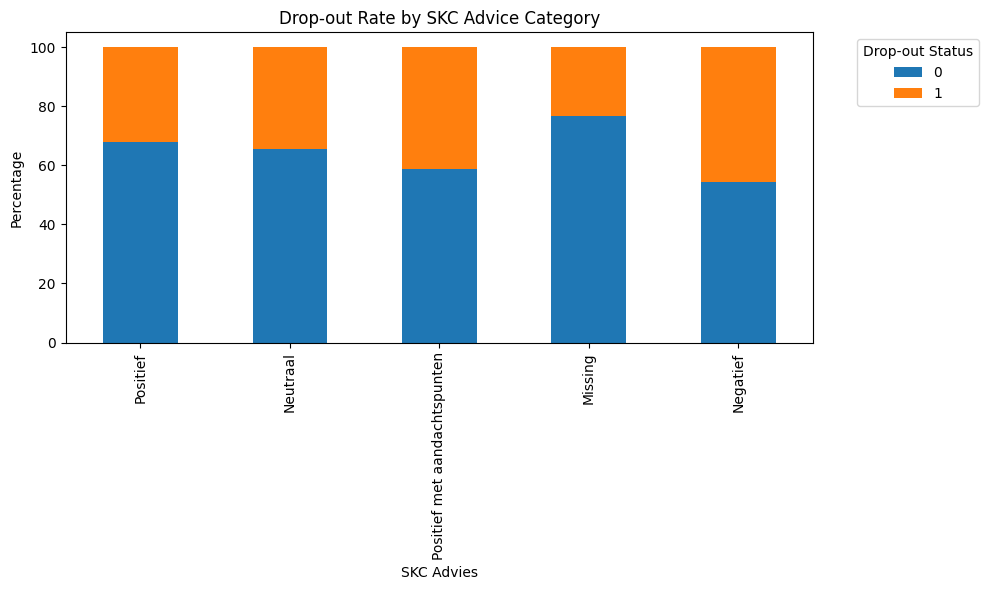

Chi-squared: 528.745842218027, p-value: 5.382556273098533e-111
sdo5_degree_drop_out                  0          1
sdo2_skc_ADVIES_DEF                               
Positief                      67.907898  32.092102
Neutraal                      65.394437  34.605563
Positief met aandachtspunten  58.620222  41.379778
Negatief                      54.516129  45.483871


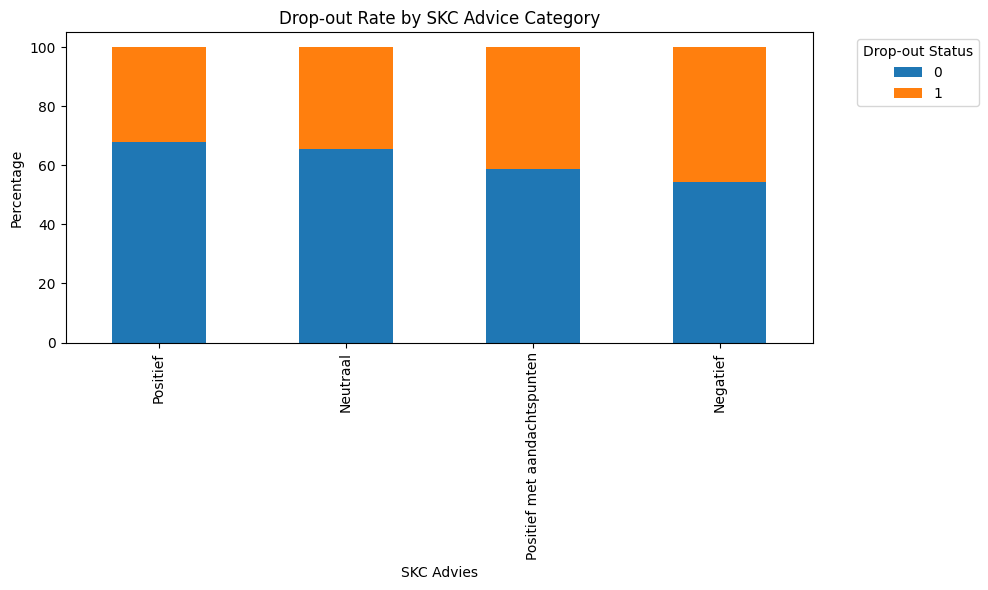

Chi-squared: 237.5930474577672, p-value: 3.154995110959308e-51


In [31]:
# Analyse relation of sdo2_skc_ADVIES_DEF with drop-out, and include missing data
# Include number of students who dropped out per SKC advice category
data['sdo2_skc_ADVIES_DEF'] = data['sdo2_skc_ADVIES_DEF'].fillna('Missing')
data['sdo5_degree_drop_out'] = data['sdo5_degree_drop_out'].fillna('Missing')
sdo_skc_dropout = data.groupby('sdo2_skc_ADVIES_DEF')['sdo5_degree_drop_out'].value_counts(normalize=True).unstack().fillna(0) * 100

# Total number of students per SKC advice category, with percentages
print(data['sdo2_skc_ADVIES_DEF'].value_counts(normalize=True) * 100)

# First look at how many students dropped out per SKC advice category
drop_out_per_SKC_collegeyear = data.groupby('sdo2_skc_ADVIES_DEF')['sdo5_degree_COLLEGEJAAR'].value_counts().unstack().fillna(0)
print(drop_out_per_SKC_collegeyear)

# Visualize as a line graph: each advice type is a line over the college years
drop_out_per_SKC_collegeyear.T.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Aantal studenten per SKC advies over collegejaren')
plt.ylabel('Aantal studenten')
plt.xlabel('Collegejaar')
plt.legend(title='SKC Advies', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Some advice categories have very few students, exclude them from significant analysis
# Exclude studies with less than 100 students in that category
sdo_skc_counts = data['sdo2_skc_ADVIES_DEF'].value_counts()
valid_skc_categories = sdo_skc_counts[sdo_skc_counts >= 200].index
sdo_skc_dropout = sdo_skc_dropout.loc[valid_skc_categories]

# Print the drop-out rates by SKC advice category
print(sdo_skc_dropout)

# Visualize the results
sdo_skc_dropout.plot(kind='bar', stacked=True, figsize=(10, 6), title='Drop-out Rate by SKC Advice Category')
plt.ylabel('Percentage')
plt.xlabel('SKC Advies')
plt.legend(title='Drop-out Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Are any of the differences significant?
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data['sdo2_skc_ADVIES_DEF'], data['sdo5_degree_drop_out'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared: {chi2}, p-value: {p}")

# Exlude 'Missing' category for significance testing
sdo_skc_dropout = sdo_skc_dropout.drop(index='Missing', errors='ignore')

# Print the drop-out rates by SKC advice category
print(sdo_skc_dropout)

# Visualize the results
sdo_skc_dropout.plot(kind='bar', stacked=True, figsize=(10, 6), title='Drop-out Rate by SKC Advice Category')
plt.ylabel('Percentage')
plt.xlabel('SKC Advies')
plt.legend(title='Drop-out Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Are any of the differences significant?
#Exclude categories with less than 100 students
data_no_small = data[data['sdo2_skc_ADVIES_DEF'].isin(valid_skc_categories)]

#Exclude 'Missing' category for significance testing
data_no_missing = data_no_small[data_no_small['sdo2_skc_ADVIES_DEF'] != 'Missing']
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data_no_missing['sdo2_skc_ADVIES_DEF'], data['sdo5_degree_drop_out'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared: {chi2}, p-value: {p}")

### Results
SKC Advice type has a strong significant relationship with HU freshman drop-out (p << 0.001). Interestingly, a lot of students (10.7%) that start a degree do not have any SKC advice type (i.e. `Missing` advice type) and this group of students shows the lowest drop-out rates (23.3%). When we exclude this SKC advice type, the strong significant effect between SKC advice type and HU freshman drop-out remains (p << 0.001), indicating that the 'actual' SKC advice types also have a strong relation with drop-out. 

Highest drop-out was observed for students with a `Negatief` advice type (45.5 of students drop-out in their first year), followed by `Positief met aandachtspunten` and `Neutraal` (41.4% and 34.6% respectively). Lowest drop-out was observed in students that received a `Positief` advice type (32.1%).